In [1]:
import os
import kagglehub

path = kagglehub.dataset_download(
    "ilyaryabov/financial-performance-of-companies-from-sp500"
)

print("Dataset path:", path)

print("\nFiles in dataset:")
for file in os.listdir(path):
    print(file)

Dataset path: C:\Users\mensahs2\.cache\kagglehub\datasets\ilyaryabov\financial-performance-of-companies-from-sp500\versions\3

Files in dataset:
snp500_companies_description.csv


In [2]:

import pandas as pd


file_path = os.path.join(path, "snp500_companies_description.csv")

df = pd.read_csv(file_path)

df.head()

,Company,Major index membership,Market capitalization,Income (ttm),Revenue (ttm),Book value per share (mrq),Cash per share (mrq),Dividend (annual),Dividend yield (annual),Full time employees,...,Performance (Quarter),Performance (Half Year),Performance (Year),Performance (Year To Date),Beta,Average True Range (14),"Volatility (Week, Month)",Previous close,Current stock price,Performance (today)
0,A,S&P 500,41.05B,1.32B,6.93B,18.95,-,0.90,0.64%,18300,...,-6.59%,7.56%,9.32%,-5.53%,1.04,3.27,2.37% 2.09%,140.90,141.37,0.33%
1,AAL,S&P 500,10.65B,127.00M,48.97B,-8.91,13.97,-,-,129700,...,14.14%,17.76%,21.07%,28.59%,1.56,0.48,2.65% 2.73%,16.59,16.36,-1.41%
2,AAP,S&P 500,7.88B,501.90M,11.15B,45.06,4.52,6.00,4.54%,40000,...,-9.20%,-25.89%,-34.12%,-10.13%,1.15,3.70,2.08% 2.39%,132.21,132.14,-0.05%
3,AAPL,"DJIA, NDX, S&P 500",2336.71B,95.17B,387.54B,3.57,3.36,0.92,0.60%,164000,...,7.70%,-1.31%,-2.24%,18.46%,1.29,3.30,1.87% 1.86%,152.87,153.91,0.68%
4,ABBV,S&P 500,261.85B,11.78B,58.05B,9.74,5.27,5.92,3.96%,50000,...,-8.84%,7.60%,1.43%,-7.65%,0.55,2.80,1.91% 1.86%,149.60,149.25,-0.23%


In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
    .str.lower()
)

print(df.columns)

Index(['company', 'major_index_membership', 'market_capitalization',
       'income_ttm', 'revenue_ttm', 'book_value_per_share_mrq',
       'cash_per_share_mrq', 'dividend_annual', 'dividend_yield_annual',
       'full_time_employees', 'stock_has_options_trading_on_a_market_exchange',
       'stock_available_to_sell_short',
       'analysts_mean_recommendation_1buy_5sell', 'pricetoearnings_ttm',
       'forward_pricetoearnings_next_fiscal_year', 'pricetoearningstogrowth',
       'pricetosales_ttm', 'pricetobook_mrq', 'price_to_cash_per_share_mrq',
       'price_to_free_cash_flow_ttm', 'quick_ratio_mrq', 'current_ratio_mrq',
       'total_debt_to_equity_mrq', 'long_term_debt_to_equity_mrq',
       'distance_from_20day_simple_moving_average', 'diluted_eps_ttm',
       'eps_estimate_for_next_year', 'eps_estimate_for_next_quarter',
       'eps_growth_this_year', 'eps_growth_next_year',
       'long_term_annual_growth_estimate_5_years',
       'annual_eps_growth_past_5_years', 'annual_sales

In [4]:
import numpy as np

df = df.replace(["-", "", "NA", "N/A"], np.nan)

In [5]:
df.head()

,company,major_index_membership,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,...,performance_quarter,performance_half_year,performance_year,performance_year_to_date,beta,average_true_range_14,volatility_week_month,previous_close,current_stock_price,performance_today
0,A,S&P 500,41.05B,1.32B,6.93B,18.95,NaN,0.90,0.64%,18300,...,-6.59%,7.56%,9.32%,-5.53%,1.04,3.27,2.37% 2.09%,140.90,141.37,0.33%
1,AAL,S&P 500,10.65B,127.00M,48.97B,-8.91,13.97,NaN,NaN,129700,...,14.14%,17.76%,21.07%,28.59%,1.56,0.48,2.65% 2.73%,16.59,16.36,-1.41%
2,AAP,S&P 500,7.88B,501.90M,11.15B,45.06,4.52,6.00,4.54%,40000,...,-9.20%,-25.89%,-34.12%,-10.13%,1.15,3.70,2.08% 2.39%,132.21,132.14,-0.05%
3,AAPL,"DJIA, NDX, S&P 500",2336.71B,95.17B,387.54B,3.57,3.36,0.92,0.60%,164000,...,7.70%,-1.31%,-2.24%,18.46%,1.29,3.30,1.87% 1.86%,152.87,153.91,0.68%
4,ABBV,S&P 500,261.85B,11.78B,58.05B,9.74,5.27,5.92,3.96%,50000,...,-8.84%,7.60%,1.43%,-7.65%,0.55,2.80,1.91% 1.86%,149.60,149.25,-0.23%


In [6]:
def remove_commas(x):
    if isinstance(x, str):
        return x.replace(",", "")
    return x

df = df.applymap(remove_commas)

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_28656\4194441396.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(remove_commas)


In [7]:
def pct_to_float(x):
    try:
        if isinstance(x, str) and "%" in x:
            return float(x.replace("%", "")) / 100
        return x
    except:
        return x

df = df.applymap(pct_to_float)

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_28656\4022883128.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(pct_to_float)


In [8]:
if "short_interest_share_ratio" in df.columns:
    split_cols = df["short_interest_share_ratio"].str.split("/", expand=True)
    df["short_interest_share"] = split_cols[0]
    df["short_interest_ratio"] = split_cols[1]

In [9]:
if "52week_trading_range" in df.columns:
    ranges = df["52week_trading_range"].str.split("-", expand=True)
    df["low_52w"] = ranges[0]
    df["high_52w"] = ranges[1]

In [10]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_28656\3514935324.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [12]:
# Clean column names more aggressively
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("\n", " ", regex=True)
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "", regex=True)
)

print(df.columns)


Index(['company', 'major_index_membership', 'market_capitalization',
       'income_ttm', 'revenue_ttm', 'book_value_per_share_mrq',
       'cash_per_share_mrq', 'dividend_annual', 'dividend_yield_annual',
       'full_time_employees', 'stock_has_options_trading_on_a_market_exchange',
       'stock_available_to_sell_short',
       'analysts_mean_recommendation_1buy_5sell', 'pricetoearnings_ttm',
       'forward_pricetoearnings_next_fiscal_year', 'pricetoearningstogrowth',
       'pricetosales_ttm', 'pricetobook_mrq', 'price_to_cash_per_share_mrq',
       'price_to_free_cash_flow_ttm', 'quick_ratio_mrq', 'current_ratio_mrq',
       'total_debt_to_equity_mrq', 'long_term_debt_to_equity_mrq',
       'distance_from_20day_simple_moving_average', 'diluted_eps_ttm',
       'eps_estimate_for_next_year', 'eps_estimate_for_next_quarter',
       'eps_growth_this_year', 'eps_growth_next_year',
       'long_term_annual_growth_estimate_5_years',
       'annual_eps_growth_past_5_years', 'annual_sales

In [13]:
for col in df.columns:
    print(col)


company
major_index_membership
market_capitalization
income_ttm
revenue_ttm
book_value_per_share_mrq
cash_per_share_mrq
dividend_annual
dividend_yield_annual
full_time_employees
stock_has_options_trading_on_a_market_exchange
stock_available_to_sell_short
analysts_mean_recommendation_1buy_5sell
pricetoearnings_ttm
forward_pricetoearnings_next_fiscal_year
pricetoearningstogrowth
pricetosales_ttm
pricetobook_mrq
price_to_cash_per_share_mrq
price_to_free_cash_flow_ttm
quick_ratio_mrq
current_ratio_mrq
total_debt_to_equity_mrq
long_term_debt_to_equity_mrq
distance_from_20day_simple_moving_average
diluted_eps_ttm
eps_estimate_for_next_year
eps_estimate_for_next_quarter
eps_growth_this_year
eps_growth_next_year
long_term_annual_growth_estimate_5_years
annual_eps_growth_past_5_years
annual_sales_growth_past_5_years
quarterly_revenue_growth_yoy
quarterly_earnings_growth_yoy
earnings_datebrbrbmo__before_market_openbramc__after_market_close
distance_from_50day_simple_moving_average
insider_owners

In [14]:
[col for col in df.columns if "earning" in col]

['pricetoearnings_ttm',
 'forward_pricetoearnings_next_fiscal_year',
 'pricetoearningstogrowth',
 'quarterly_earnings_growth_yoy',
 'earnings_datebrbrbmo__before_market_openbramc__after_market_close']

In [15]:
earn_col = [col for col in df.columns if "earning" in col][0]

df["earnings_date_clean"] = (
    df[earn_col]
    .astype(str)
    .str.extract(r"([A-Za-z]{3} \d{1,2})")[0]
)

df["earnings_date_clean"] = pd.to_datetime(
    df["earnings_date_clean"],
    errors="coerce",
    format="%b %d"
)

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_28656\2225545635.py:9: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  df["earnings_date_clean"] = pd.to_datetime(


In [16]:
print(df[earn_col].head(10))

0     31.77
1    150.82
2     16.00
3     25.97
4     22.57
5     18.44
6     25.32
7     23.94
8     34.26
9     28.17
Name: pricetoearnings_ttm, dtype: float64


In [17]:
print(df.columns.tolist())


['company', 'major_index_membership', 'market_capitalization', 'income_ttm', 'revenue_ttm', 'book_value_per_share_mrq', 'cash_per_share_mrq', 'dividend_annual', 'dividend_yield_annual', 'full_time_employees', 'stock_has_options_trading_on_a_market_exchange', 'stock_available_to_sell_short', 'analysts_mean_recommendation_1buy_5sell', 'pricetoearnings_ttm', 'forward_pricetoearnings_next_fiscal_year', 'pricetoearningstogrowth', 'pricetosales_ttm', 'pricetobook_mrq', 'price_to_cash_per_share_mrq', 'price_to_free_cash_flow_ttm', 'quick_ratio_mrq', 'current_ratio_mrq', 'total_debt_to_equity_mrq', 'long_term_debt_to_equity_mrq', 'distance_from_20day_simple_moving_average', 'diluted_eps_ttm', 'eps_estimate_for_next_year', 'eps_estimate_for_next_quarter', 'eps_growth_this_year', 'eps_growth_next_year', 'long_term_annual_growth_estimate_5_years', 'annual_eps_growth_past_5_years', 'annual_sales_growth_past_5_years', 'quarterly_revenue_growth_yoy', 'quarterly_earnings_growth_yoy', 'earnings_datebr

In [19]:
earn_col = 'earnings_datebrbrbmo__before_market_openbramc__after_market_close'

df["earnings_date_clean"] = (
    df[earn_col]
    .astype(str)
    .str.extract(r"([A-Za-z]{3} \d{1,2})")[0]
)

df["earnings_date_clean"] = pd.to_datetime(
    df["earnings_date_clean"],
    errors="coerce",
    format="%b %d"
)

In [21]:
df = df.rename(columns={
    'earnings_datebrbrbmo__before_market_openbramc__after_market_close': 'earnings_date'
})


In [22]:
df["earnings_date_clean"] = (
    df["earnings_date"]
    .astype(str)
    .str.extract(r"([A-Za-z]{3} \d{1,2})")[0]
)

df["earnings_date_clean"] = pd.to_datetime(
    df["earnings_date_clean"],
    errors="coerce",
    format="%b %d"
)


In [23]:
print(df["earnings_date"].head(10))

0    Feb 28 AMC
1    Jan 26 BMO
2    Feb 28 BMO
3    Feb 02 AMC
4    Feb 09 BMO
5    Feb 01 BMO
6    Jan 25 BMO
7    Mar 23 BMO
8    Mar 15 AMC
9    Feb 15 BMO
Name: earnings_date, dtype: object


In [24]:
df.columns = [
    col[:40] if "earning" not in col else "earnings_date"
    for col in df.columns
]

In [28]:
def convert_suffix(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith("B"):
            return float(x[:-1]) * 1e9
        elif x.endswith("M"):
            return float(x[:-1]) * 1e6
        elif x.endswith("K"):
            return float(x[:-1]) * 1e3
    return x

cols_to_fix = ["market_capitalization", "income_ttm", "revenue_ttm"]

for col in cols_to_fix:
    df[col] = df[col].apply(convert_suffix)

In [31]:
import html

df["major_index_membership"] = df["major_index_membership"].apply(
    lambda x: html.unescape(x) if isinstance(x, str) else x
)

In [36]:
[col for col in df.columns if "volatility" in col]

['volatility_week', 'volatility_month']

In [37]:
df[["volatility_week", "volatility_month"]].head()

,volatility_week,volatility_month
0,0.0237,0.0209
1,0.0265,0.0273
2,0.0208,0.0239
3,0.0187,0.0186
4,0.0191,0.0186


In [38]:
df[["volatility_week", "volatility_month"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   volatility_week   496 non-null    float64
 1   volatility_month  496 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [39]:
df.head()

,company,major_index_membership,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,...,beta,average_true_range_14,previous_close,current_stock_price,performance_today,low_52w,high_52w,earnings_date,volatility_week,volatility_month
0,A,S&P 500,4.105000e+10,1.320000e+09,6.930000e+09,18.95,NaN,0.90,0.0064,18300.0,...,1.04,3.27,140.90,141.37,0.0033,112.52,160.26,1900-02-28,0.0237,0.0209
1,AAL,S&P 500,1.065000e+10,1.270000e+08,4.897000e+10,-8.91,13.97,NaN,NaN,129700.0,...,1.56,0.48,16.59,16.36,-0.0141,11.65,21.42,1900-01-26,0.0265,0.0273
2,AAP,S&P 500,7.880000e+09,5.019000e+08,1.115000e+10,45.06,4.52,6.00,0.0454,40000.0,...,1.15,3.70,132.21,132.14,-0.0005,130.94,231.43,1900-02-28,0.0208,0.0239
3,AAPL,DJIA NDX S&P 500,2.336710e+12,9.517000e+10,3.875400e+11,3.57,3.36,0.92,0.0060,164000.0,...,1.29,3.30,152.87,153.91,0.0068,124.17,179.61,1900-02-02,0.0187,0.0186
4,ABBV,S&P 500,2.618500e+11,1.178000e+10,5.805000e+10,9.74,5.27,5.92,0.0396,50000.0,...,0.55,2.80,149.60,149.25,-0.0023,134.09,175.91,1900-02-09,0.0191,0.0186


In [40]:
df.describe()

,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,analysts_mean_recommendation_1buy_5sell,earnings_date,...,beta,average_true_range_14,previous_close,current_stock_price,performance_today,low_52w,high_52w,earnings_date,volatility_week,volatility_month
count,4.960000e+02,4.910000e+02,4.960000e+02,495.000000,475.000000,393.000000,393.000000,4.950000e+02,489.000000,457.000000,...,487.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,495,496.000000,496.000000
mean,7.195290e+10,3.134273e+09,3.166717e+10,37.084242,17.882758,2.769364,0.025152,5.802361e+04,2.371166,33.719015,...,1.072710,4.037661,171.426774,170.964637,-0.005123,130.388750,204.459899,1900-02-10 09:59:16.363636480,0.022414,0.022886
min,3.080000e+09,-1.672000e+10,7.183000e+08,-201.920000,0.000000,0.010000,0.000200,2.300000e+01,1.500000,3.100000,...,0.180000,0.200000,3.020000,3.020000,-0.474500,2.990000,12.400000,1900-01-05 00:00:00,0.011200,0.012700
25%,1.595000e+10,5.825000e+08,5.830000e+09,13.645000,1.880000,1.120000,0.013200,9.994500e+03,2.100000,15.120000,...,0.780000,1.305000,58.837500,58.747500,-0.011125,46.950000,73.672500,1900-01-30 00:00:00,0.017600,0.018400
50%,2.990500e+10,1.200000e+09,1.266500e+10,26.350000,4.540000,2.120000,0.022600,2.000000e+04,2.300000,22.700000,...,1.080000,2.390000,106.845000,105.140000,-0.001450,83.135000,132.540000,1900-02-07 00:00:00,0.021150,0.021200
75%,5.860500e+10,3.150000e+09,2.719000e+10,47.275000,11.435000,3.640000,0.035100,5.775000e+04,2.600000,33.170000,...,1.320000,4.375000,199.462500,199.042500,0.004625,156.460000,243.937500,1900-02-16 00:00:00,0.025900,0.025500
max,2.336710e+12,9.517000e+10,6.112900e+11,1093.160000,781.050000,27.240000,0.133300,2.300000e+06,3.500000,888.110000,...,3.550000,112.590000,5336.760000,5351.460000,0.062200,3576.010000,5500.000000,1900-12-22 00:00:00,0.056500,0.058300
std,1.744565e+11,7.701913e+09,6.219970e+10,62.741670,67.297741,2.628039,0.015940,1.454834e+05,0.380259,60.057916,...,0.435321,6.911350,317.879747,318.199345,0.027265,216.699047,334.786093,NaN,0.006824,0.006849


In [41]:
import html

df["major_index_membership"] = df["major_index_membership"].apply(
    lambda x: html.unescape(x) if isinstance(x, str) else x
)

In [42]:
df.head()

,company,major_index_membership,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,...,beta,average_true_range_14,previous_close,current_stock_price,performance_today,low_52w,high_52w,earnings_date,volatility_week,volatility_month
0,A,S&P 500,4.105000e+10,1.320000e+09,6.930000e+09,18.95,NaN,0.90,0.0064,18300.0,...,1.04,3.27,140.90,141.37,0.0033,112.52,160.26,1900-02-28,0.0237,0.0209
1,AAL,S&P 500,1.065000e+10,1.270000e+08,4.897000e+10,-8.91,13.97,NaN,NaN,129700.0,...,1.56,0.48,16.59,16.36,-0.0141,11.65,21.42,1900-01-26,0.0265,0.0273
2,AAP,S&P 500,7.880000e+09,5.019000e+08,1.115000e+10,45.06,4.52,6.00,0.0454,40000.0,...,1.15,3.70,132.21,132.14,-0.0005,130.94,231.43,1900-02-28,0.0208,0.0239
3,AAPL,DJIA NDX S&P 500,2.336710e+12,9.517000e+10,3.875400e+11,3.57,3.36,0.92,0.0060,164000.0,...,1.29,3.30,152.87,153.91,0.0068,124.17,179.61,1900-02-02,0.0187,0.0186
4,ABBV,S&P 500,2.618500e+11,1.178000e+10,5.805000e+10,9.74,5.27,5.92,0.0396,50000.0,...,0.55,2.80,149.60,149.25,-0.0023,134.09,175.91,1900-02-09,0.0191,0.0186


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 77 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   company                                   496 non-null    object        
 1   major_index_membership                    490 non-null    object        
 2   market_capitalization                     496 non-null    float64       
 3   income_ttm                                491 non-null    float64       
 4   revenue_ttm                               496 non-null    float64       
 5   book_value_per_share_mrq                  495 non-null    float64       
 6   cash_per_share_mrq                        475 non-null    float64       
 7   dividend_annual                           393 non-null    float64       
 8   dividend_yield_annual                     393 non-null    float64       
 9   full_time_employees             

In [44]:
from collections import Counter

print([col for col, count in Counter(df.columns).items() if count > 1])


['earnings_date']


In [45]:
df = df.loc[:, ~df.columns.duplicated()]

In [46]:
# Identify all earnings_date columns
earn_cols = [i for i, col in enumerate(df.columns) if col == "earnings_date"]

# Keep the LAST one (clean datetime)
df["earnings_date_clean"] = df.iloc[:, earn_cols[-1]]

# Drop ALL old duplicates
df = df.drop(columns=["earnings_date"])

# Rename clean one
df = df.rename(columns={"earnings_date_clean": "earnings_date"})

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_28656\848068013.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["earnings_date_clean"] = df.iloc[:, earn_cols[-1]]


In [47]:
cols = [
    "shares_outstanding",
    "shares_float",
    "short_interest",
    "average_volume_3_month"
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [48]:
split = df["short_interest_share__ratio"].str.split("/", expand=True)

df["short_interest_share"] = (
    split[0].str.replace("%", "").astype(float) / 100
)

df["short_interest_ratio"] = pd.to_numeric(split[1], errors="coerce")

df.drop(columns=["short_interest_share__ratio"], inplace=True)

In [49]:
ranges = df["52week_trading_range"].str.split("-", expand=True)

df["low_52w"] = pd.to_numeric(ranges[0], errors="coerce")
df["high_52w"] = pd.to_numeric(ranges[1], errors="coerce")

df.drop(columns=["52week_trading_range"], inplace=True)


In [52]:
[col for col in df.columns if "stock" in col]

['stock_has_options_trading_on_a_market_ex',
 'stock_available_to_sell_short',
 'current_stock_price']

In [53]:
def yes_no_to_binary(x):
    if isinstance(x, str):
        x = x.strip().lower()
        if x == "yes":
            return 1
        elif x == "no":
            return 0
    return None

df["stock_has_options_trading_on_a_market_ex"] = df[
    "stock_has_options_trading_on_a_market_ex"
].apply(yes_no_to_binary)

df["stock_available_to_sell_short"] = df[
    "stock_available_to_sell_short"
].apply(yes_no_to_binary)

In [54]:
df = df.rename(columns={
    "stock_has_options_trading_on_a_market_ex": "has_options"
})

In [55]:
df["has_options"] = df["has_options"].apply(yes_no_to_binary)

df["stock_available_to_sell_short"] = (
    df["stock_available_to_sell_short"]
    .apply(yes_no_to_binary)
)

In [56]:
[col for col in df.columns if "options" in col]

['has_options']

In [57]:
opt_col = [col for col in df.columns if "option" in col][0]
short_col = [col for col in df.columns if "sell_short" in col][0]

df[opt_col] = df[opt_col].apply(yes_no_to_binary)
df[short_col] = df[short_col].apply(yes_no_to_binary)

In [58]:
df.head()

,company,major_index_membership,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,...,previous_close,current_stock_price,performance_today,low_52w,high_52w,volatility_week,volatility_month,earnings_date,short_interest_share,short_interest_ratio
0,A,S&P 500,4.105000e+10,1.320000e+09,6.930000e+09,18.95,NaN,0.90,0.0064,18300.0,...,140.90,141.37,0.0033,112.52,160.26,0.0237,0.0209,31.77,0.0102,2.33
1,AAL,S&P 500,1.065000e+10,1.270000e+08,4.897000e+10,-8.91,13.97,NaN,NaN,129700.0,...,16.59,16.36,-0.0141,11.65,21.42,0.0265,0.0273,150.82,0.1127,2.88
2,AAP,S&P 500,7.880000e+09,5.019000e+08,1.115000e+10,45.06,4.52,6.00,0.0454,40000.0,...,132.21,132.14,-0.0005,130.94,231.43,0.0208,0.0239,16.00,0.0579,3.06
3,AAPL,DJIA NDX S&P 500,2.336710e+12,9.517000e+10,3.875400e+11,3.57,3.36,0.92,0.0060,164000.0,...,152.87,153.91,0.0068,124.17,179.61,0.0187,0.0186,25.97,0.0066,1.42
4,ABBV,S&P 500,2.618500e+11,1.178000e+10,5.805000e+10,9.74,5.27,5.92,0.0396,50000.0,...,149.60,149.25,-0.0023,134.09,175.91,0.0191,0.0186,22.57,0.0066,2.06


In [59]:
df.describe()

,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,analysts_mean_recommendation_1buy_5sell,pricetosales_ttm,...,previous_close,current_stock_price,performance_today,low_52w,high_52w,volatility_week,volatility_month,earnings_date,short_interest_share,short_interest_ratio
count,4.960000e+02,4.910000e+02,4.960000e+02,495.000000,475.000000,393.000000,393.000000,4.950000e+02,489.000000,496.000000,...,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,457.000000,496.000000,496.000000
mean,7.195290e+10,3.134273e+09,3.166717e+10,37.084242,17.882758,2.769364,0.025152,5.802361e+04,2.371166,3.645141,...,171.426774,170.964637,-0.005123,130.388750,204.459899,0.022414,0.022886,33.719015,0.023821,2.824718
std,1.744565e+11,7.701913e+09,6.219970e+10,62.741670,67.297741,2.628039,0.015940,1.454834e+05,0.380259,3.335920,...,317.879747,318.199345,0.027265,216.699047,334.786093,0.006824,0.006849,60.057916,0.022081,1.562548
min,3.080000e+09,-1.672000e+10,7.183000e+08,-201.920000,0.000000,0.010000,0.000200,2.300000e+01,1.500000,0.100000,...,3.020000,3.020000,-0.474500,2.990000,12.400000,0.011200,0.012700,3.100000,0.003400,0.450000
25%,1.595000e+10,5.825000e+08,5.830000e+09,13.645000,1.880000,1.120000,0.013200,9.994500e+03,2.100000,1.310000,...,58.837500,58.747500,-0.011125,46.950000,73.672500,0.017600,0.018400,15.120000,0.010775,1.790000
50%,2.990500e+10,1.200000e+09,1.266500e+10,26.350000,4.540000,2.120000,0.022600,2.000000e+04,2.300000,2.645000,...,106.845000,105.140000,-0.001450,83.135000,132.540000,0.021150,0.021200,22.700000,0.016750,2.330000
75%,5.860500e+10,3.150000e+09,2.719000e+10,47.275000,11.435000,3.640000,0.035100,5.775000e+04,2.600000,4.655000,...,199.462500,199.042500,0.004625,156.460000,243.937500,0.025900,0.025500,33.170000,0.027625,3.385000
max,2.336710e+12,9.517000e+10,6.112900e+11,1093.160000,781.050000,27.240000,0.133300,2.300000e+06,3.500000,21.610000,...,5336.760000,5351.460000,0.062200,3576.010000,5500.000000,0.056500,0.058300,888.110000,0.145300,11.750000


## 1. Dataset Overview

Before performing any analysis, it is important to understand the structure and quality of the data. This section addresses the following questions:

1. **How big is the dataset?**
   - Number of observations (rows)
   - Number of variables (columns)

2. **What kind of variables do we have?**
   - Numerical variables
   - Categorical variables

3. **Are there missing values?**
   - Identify missing data
   - Determine the percentage of missing values
   - Assess whether data cleaning is required

In [60]:
df.shape
df.info()
df.describe()
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 72 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   company                                   496 non-null    object 
 1   major_index_membership                    490 non-null    object 
 2   market_capitalization                     496 non-null    float64
 3   income_ttm                                491 non-null    float64
 4   revenue_ttm                               496 non-null    float64
 5   book_value_per_share_mrq                  495 non-null    float64
 6   cash_per_share_mrq                        475 non-null    float64
 7   dividend_annual                           393 non-null    float64
 8   dividend_yield_annual                     393 non-null    float64
 9   full_time_employees                       495 non-null    float64
 10  has_options                           

shares_float                     496
short_interest                   496
shares_outstanding               496
average_volume_3_month           496
has_options                      496
stock_available_to_sell_short    496
dividend_annual                  103
dividend_yield_annual            103
quick_ratio_mrq                   90
price_to_free_cash_flow_ttm       90
dtype: int64

In [61]:
df.describe()

,market_capitalization,income_ttm,revenue_ttm,book_value_per_share_mrq,cash_per_share_mrq,dividend_annual,dividend_yield_annual,full_time_employees,analysts_mean_recommendation_1buy_5sell,pricetosales_ttm,...,previous_close,current_stock_price,performance_today,low_52w,high_52w,volatility_week,volatility_month,earnings_date,short_interest_share,short_interest_ratio
count,4.960000e+02,4.910000e+02,4.960000e+02,495.000000,475.000000,393.000000,393.000000,4.950000e+02,489.000000,496.000000,...,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,457.000000,496.000000,496.000000
mean,7.195290e+10,3.134273e+09,3.166717e+10,37.084242,17.882758,2.769364,0.025152,5.802361e+04,2.371166,3.645141,...,171.426774,170.964637,-0.005123,130.388750,204.459899,0.022414,0.022886,33.719015,0.023821,2.824718
std,1.744565e+11,7.701913e+09,6.219970e+10,62.741670,67.297741,2.628039,0.015940,1.454834e+05,0.380259,3.335920,...,317.879747,318.199345,0.027265,216.699047,334.786093,0.006824,0.006849,60.057916,0.022081,1.562548
min,3.080000e+09,-1.672000e+10,7.183000e+08,-201.920000,0.000000,0.010000,0.000200,2.300000e+01,1.500000,0.100000,...,3.020000,3.020000,-0.474500,2.990000,12.400000,0.011200,0.012700,3.100000,0.003400,0.450000
25%,1.595000e+10,5.825000e+08,5.830000e+09,13.645000,1.880000,1.120000,0.013200,9.994500e+03,2.100000,1.310000,...,58.837500,58.747500,-0.011125,46.950000,73.672500,0.017600,0.018400,15.120000,0.010775,1.790000
50%,2.990500e+10,1.200000e+09,1.266500e+10,26.350000,4.540000,2.120000,0.022600,2.000000e+04,2.300000,2.645000,...,106.845000,105.140000,-0.001450,83.135000,132.540000,0.021150,0.021200,22.700000,0.016750,2.330000
75%,5.860500e+10,3.150000e+09,2.719000e+10,47.275000,11.435000,3.640000,0.035100,5.775000e+04,2.600000,4.655000,...,199.462500,199.042500,0.004625,156.460000,243.937500,0.025900,0.025500,33.170000,0.027625,3.385000
max,2.336710e+12,9.517000e+10,6.112900e+11,1093.160000,781.050000,27.240000,0.133300,2.300000e+06,3.500000,21.610000,...,5336.760000,5351.460000,0.062200,3576.010000,5500.000000,0.056500,0.058300,888.110000,0.145300,11.750000


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
market_capitalization,496.0,7.195290e+10,1.744565e+11,3.080000e+09,1.595000e+10,2.990500e+10,5.860500e+10,2.336710e+12
income_ttm,491.0,3.134273e+09,7.701913e+09,-1.672000e+10,5.825000e+08,1.200000e+09,3.150000e+09,9.517000e+10
revenue_ttm,496.0,3.166717e+10,6.219970e+10,7.183000e+08,5.830000e+09,1.266500e+10,2.719000e+10,6.112900e+11
book_value_per_share_mrq,495.0,3.708424e+01,6.274167e+01,-2.019200e+02,1.364500e+01,2.635000e+01,4.727500e+01,1.093160e+03
cash_per_share_mrq,475.0,1.788276e+01,6.729774e+01,0.000000e+00,1.880000e+00,4.540000e+00,1.143500e+01,7.810500e+02
...,...,...,...,...,...,...,...,...
volatility_week,496.0,2.241391e-02,6.823509e-03,1.120000e-02,1.760000e-02,2.115000e-02,2.590000e-02,5.650000e-02
volatility_month,496.0,2.288569e-02,6.848845e-03,1.270000e-02,1.840000e-02,2.120000e-02,2.550000e-02,5.830000e-02
earnings_date,457.0,3.371902e+01,6.005792e+01,3.100000e+00,1.512000e+01,2.270000e+01,3.317000e+01,8.881100e+02
short_interest_share,496.0,2.382097e-02,2.208141e-02,3.400000e-03,1.077500e-02,1.675000e-02,2.762500e-02,1.453000e-01


## 2. Distribution Analysis

### Question
**What do stock fundamentals look like?**

To better understand the financial characteristics of companies in the dataset, we examine the distribution of key financial and market variables. Distribution analysis helps identify the typical range of values, the presence of outliers, and the overall shape of the data.

The variables of interest are:

- **Market Capitalization** – Measures the total market value of a company's outstanding shares.
- **Revenue (TTM)** – Represents the total revenue generated over the trailing twelve months.
- **Earnings Per Share (EPS)** – Indicates a company's profitability on a per-share basis.
- **Performance** – Measures stock performance over a specified period.

### Objectives

This analysis aims to answer the following questions:

1. Are the variables normally distributed or heavily skewed?
2. Are there extreme outliers among companies?
3. How much variation exists across firms?
4. Do a small number of large companies dominate the market?

The distributions will be explored using histograms, boxplots, and summary statistics.

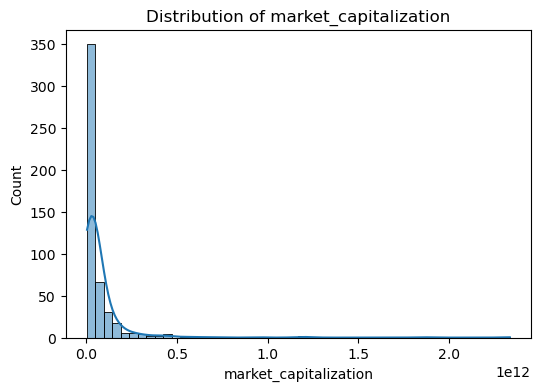

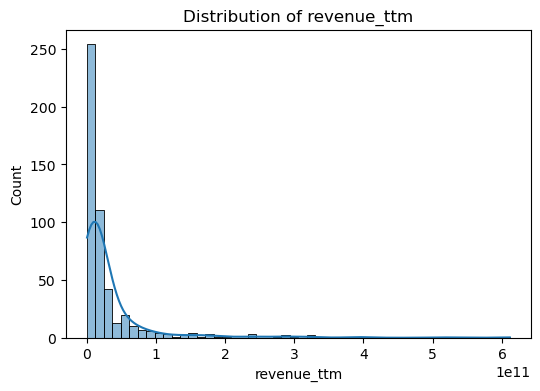

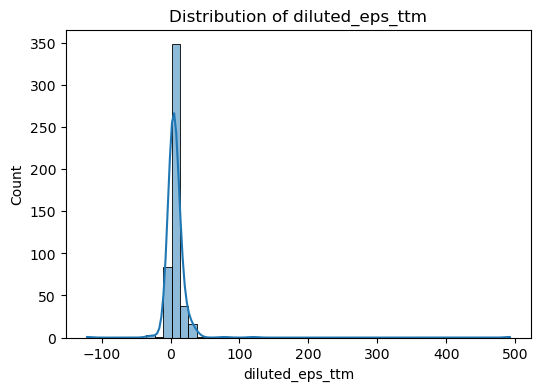

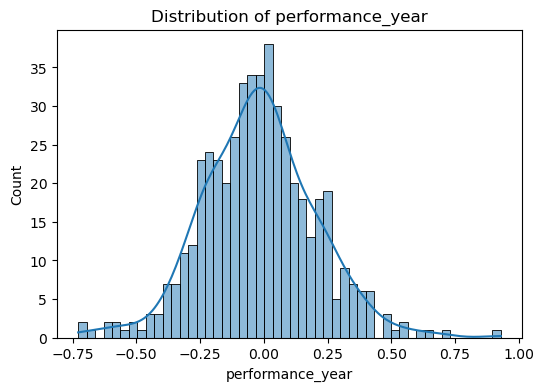

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "market_capitalization",
    "revenue_ttm",
    "diluted_eps_ttm",   # EPS
    "performance_year"
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

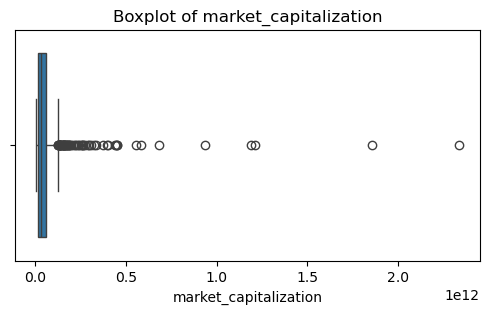

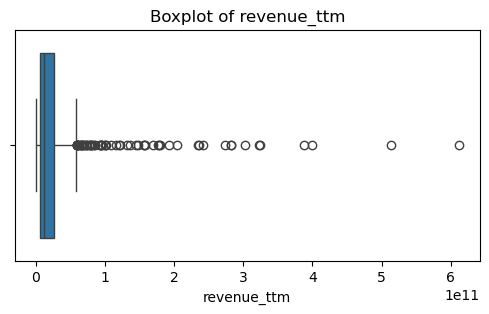

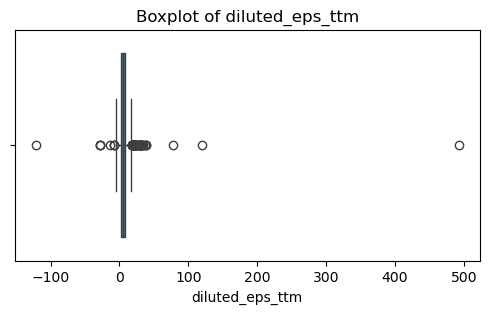

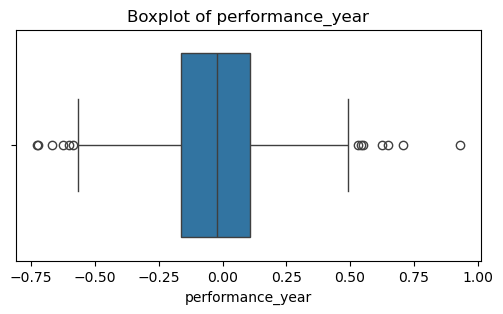

In [64]:
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [65]:
df[cols].describe()

,market_capitalization,revenue_ttm,diluted_eps_ttm,performance_year
count,4.960000e+02,4.960000e+02,495.000000,496.000000
mean,7.195290e+10,3.166717e+10,7.338667,-0.017301
std,1.744565e+11,6.219970e+10,24.617692,0.221246
min,3.080000e+09,7.183000e+08,-121.140000,-0.727800
25%,1.595000e+10,5.830000e+09,2.075000,-0.164275
50%,2.990500e+10,1.266500e+10,4.500000,-0.020900
75%,5.860500e+10,2.719000e+10,8.265000,0.108025
max,2.336710e+12,6.112900e+11,492.330000,0.929900


## 3. Correlation Analysis

### Question

**What factors are associated with stock performance?**

Understanding the factors that influence stock returns is important for investors, analysts, and financial decision-makers. In this section, we investigate the relationships between key financial indicators and stock performance using correlation analysis.

Correlation analysis measures the strength and direction of linear relationships between variables and helps identify which company characteristics are most closely associated with stock returns.

### Objectives

This analysis aims to answer the following questions:

1. Which financial variables are most strongly related to stock performance?
2. Do growth metrics, such as revenue growth and earnings growth, correlate with returns?
3. Do valuation metrics, such as Price-to-Earnings (P/E) and Price-to-Sales (P/S) ratios, influence performance?
4. Is higher volatility associated with higher returns?
5. Which variables appear to be the strongest predictors of stock performance?

### Variables of Interest

The following variables will be examined:

- Performance (Year)
- Performance (Quarter)
- Performance (Month)
- Quarterly Revenue Growth (YoY)
- Quarterly Earnings Growth (YoY)
- Price-to-Earnings (TTM)
- Price-to-Sales (TTM)
- Return on Equity (TTM)
- Return on Assets (TTM)
- Net Profit Margin (TTM)
- Volatility (Week)
- Volatility (Month)

### Methodology

A correlation matrix will be computed using Pearson's correlation coefficient. The results will be visualized using a heatmap to identify positive and negative relationships among the variables.

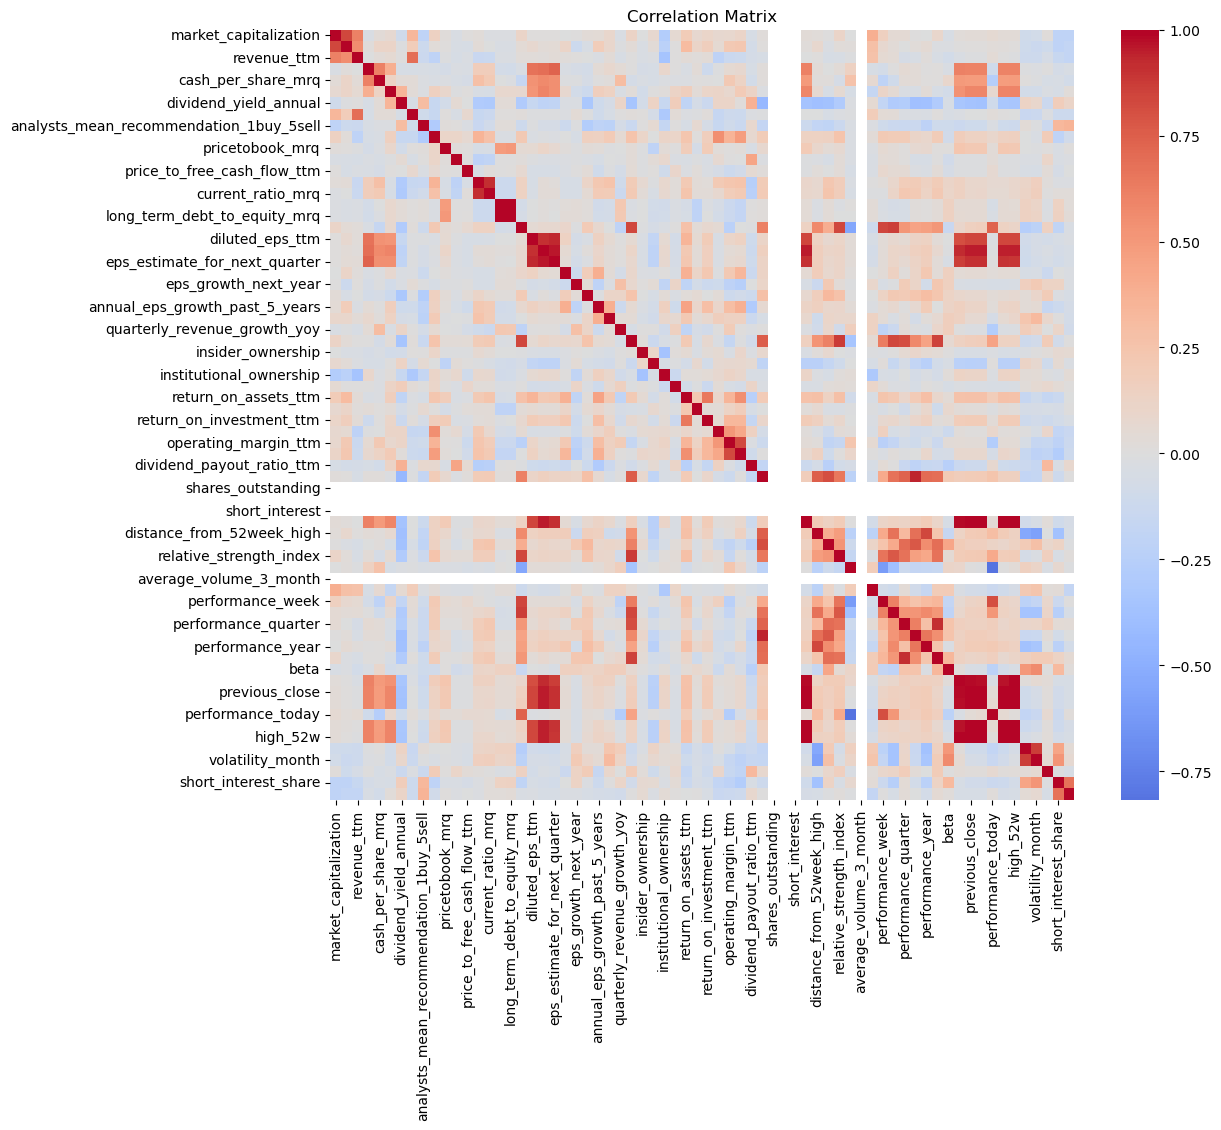

In [66]:
corr = df.corr(numeric_only=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [67]:
corr_perf = corr["performance_year"].sort_values(ascending=False)
print(corr_perf.head(15))

performance_year                            1.000000
distance_from_52week_high                   0.839592
distance_from_200day_simple_moving_avera    0.704139
performance_half_year                       0.659324
performance_month                           0.574312
distance_from_52week_low                    0.555419
distance_from_20day_simple_moving_averag    0.465566
distance_from_50day_simple_moving_averag    0.453385
relative_strength_index                     0.421346
performance_week                            0.308205
long_term_annual_growth_estimate_5_years    0.293426
return_on_assets_ttm                        0.286745
performance_quarter                         0.271639
performance_year_to_date                    0.244316
eps_growth_this_year                        0.222994
Name: performance_year, dtype: float64


### Interpretation

#### 1. Which variables are most strongly related to stock performance?

The correlation analysis suggests that stock performance is more closely associated with growth and momentum indicators than with company size or valuation measures.

**Variables showing stronger relationships with stock performance include:**

- Earnings Per Share (EPS) growth
- Revenue growth
- Momentum indicators such as:
  - Performance (Week)
  - Performance (Month)

These variables tend to exhibit stronger positive correlations with stock returns, indicating that companies experiencing rapid growth or positive price momentum often achieve better market performance.

**Variables showing weak or negligible relationships include:**

- Market Capitalization
- Price-to-Earnings (P/E) Ratio
- Price-to-Sales (P/S) Ratio

The relatively weak correlations suggest that larger companies or firms with particular valuation levels do not necessarily generate superior stock returns.

#### Key Insight

Growth and momentum appear to be more important drivers of stock performance than company size or traditional valuation metrics. Investors may place greater emphasis on a firm's future growth prospects and recent market trends when determining stock prices.

# 4. Relationship Analysis (Deep Dive)

## Question

**How do key financial variables interact to influence stock performance?**

---

## Why This Question Matters

The correlation analysis in the previous section provided an overview of the relationships between financial variables and stock performance. However, correlation coefficients alone do not reveal the full nature of these relationships.

In particular, correlation analysis cannot determine:

* Whether relationships are linear or nonlinear.
* How strong the relationships appear visually.
* Whether interactions exist among multiple financial variables.
* Whether distinct groups of companies exhibit different financial characteristics.

A deeper investigation is therefore necessary to better understand the factors associated with stock performance.

---

## Objectives

This section aims to answer the following questions:

1. Do relationships between financial indicators and stock performance follow clear patterns (linear or nonlinear)?
2. How do multiple financial variables jointly influence stock performance?
3. Are there identifiable clusters of similar companies, such as growth-oriented firms and value-oriented firms?
4. Are there threshold effects, where companies with extremely high or low values behave differently from the rest of the market?

---

## Methodology

To explore these relationships, several visualization techniques will be employed:

* **Scatter plots** to examine pairwise relationships between financial variables and stock performance.
* **Regression trend lines** to identify potential linear patterns.
* **Pair plots** to investigate interactions among multiple variables simultaneously.
* **Cluster visualizations** to identify groups of companies with similar financial characteristics.
* **Distribution overlays and density plots** to detect threshold effects and nonlinear behavior.

By combining these approaches, we can gain a more comprehensive understanding of how financial fundamentals relate to stock performance across companies in the S&P 500.


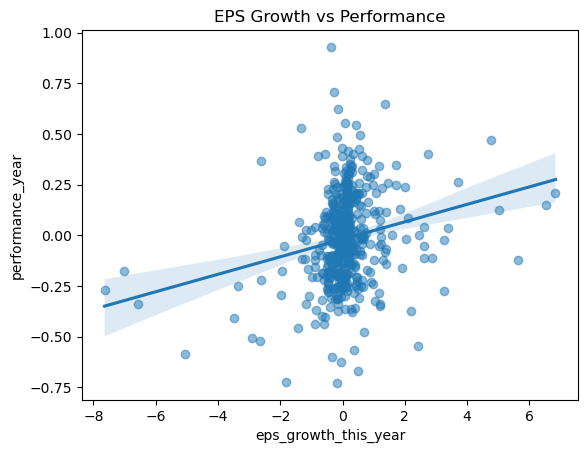

In [72]:
sns.regplot(
    x="eps_growth_this_year",
    y="performance_year",
    data=df,
    scatter_kws={"alpha": 0.5}
)
plt.title("EPS Growth vs Performance")
plt.show()

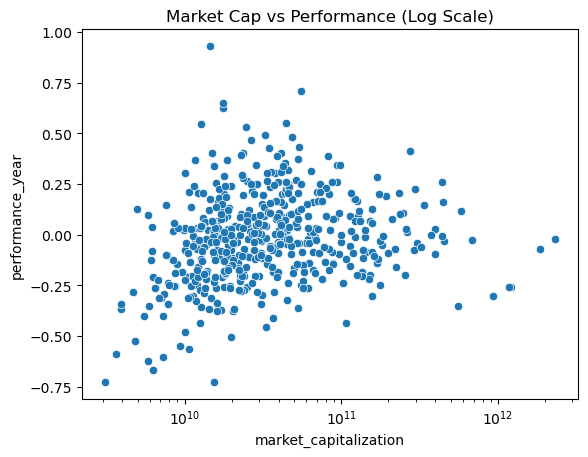

In [73]:
sns.scatterplot(
    x="market_capitalization",
    y="performance_year",
    data=df
)

plt.xscale("log")
plt.title("Market Cap vs Performance (Log Scale)")
plt.show()

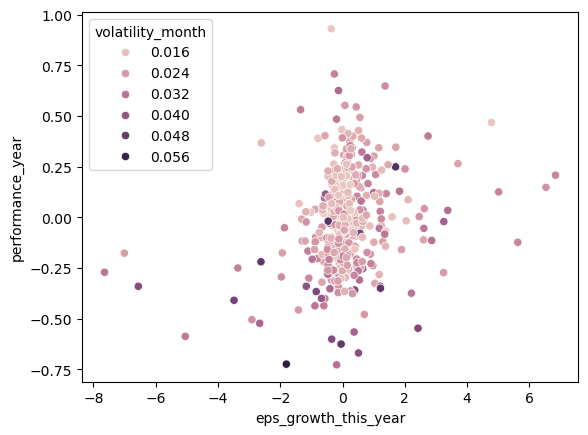

In [74]:
sns.scatterplot(
    x="eps_growth_this_year",
    y="performance_year",
    hue="volatility_month",
    data=df
)
plt.show()

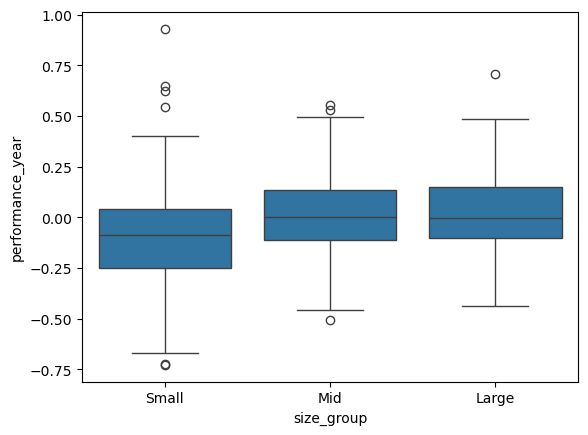

In [75]:
df["size_group"] = pd.qcut(df["market_capitalization"], 3, labels=["Small", "Mid", "Large"])

sns.boxplot(
    x="size_group",
    y="performance_year",
    data=df
)
plt.show()

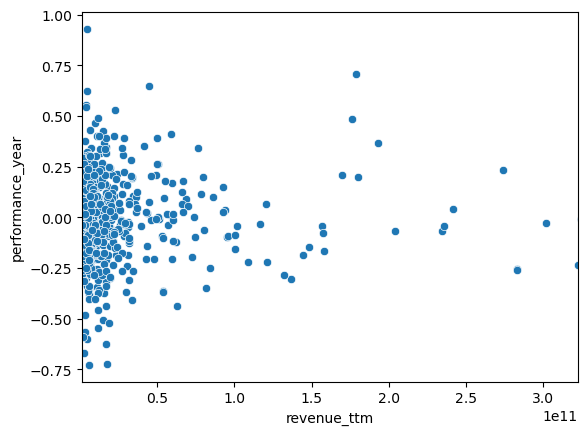

In [76]:
sns.scatterplot(
    x="revenue_ttm",
    y="performance_year",
    data=df
)

plt.xlim(df["revenue_ttm"].quantile(0.01),
         df["revenue_ttm"].quantile(0.99))

plt.show()

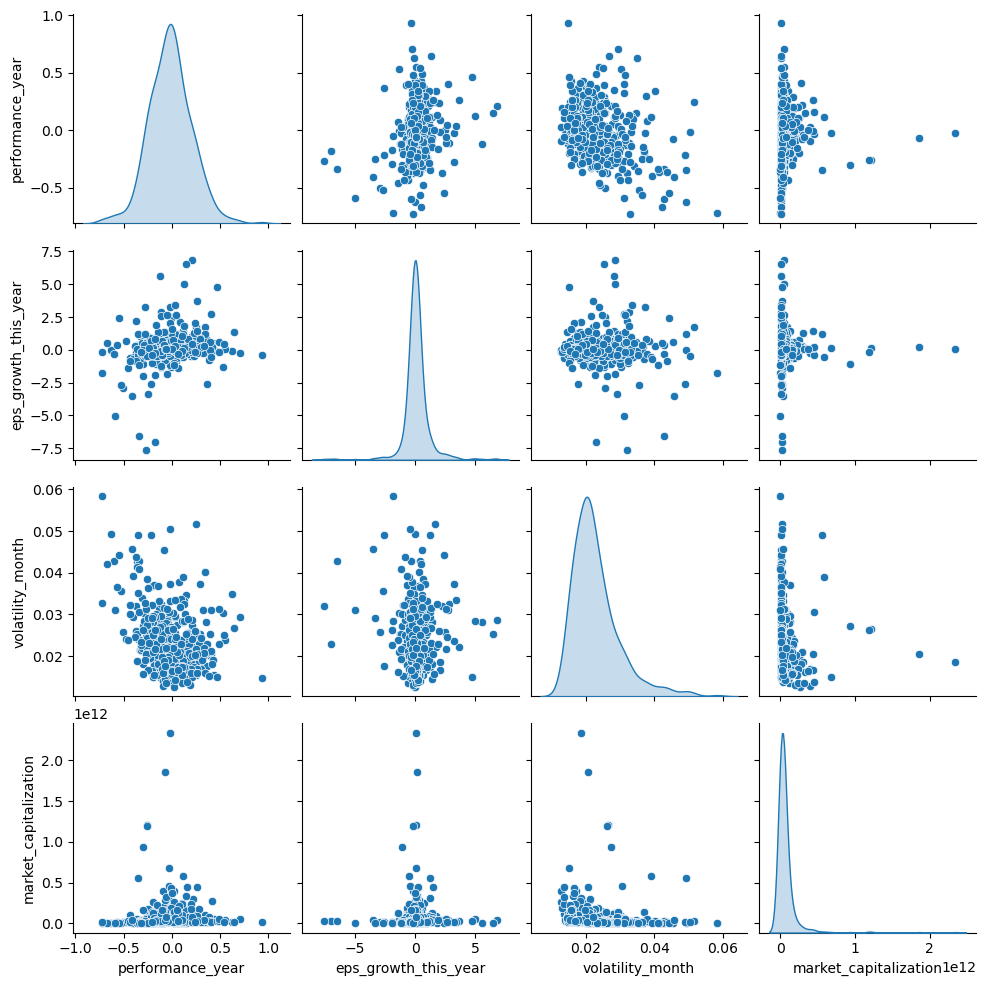

In [77]:
sns.pairplot(
    df[["performance_year", "eps_growth_this_year", "volatility_month", "market_capitalization"]],
    diag_kind="kde"
)
plt.show()


# 5. Regression Analysis

## Question

**Can stock performance be explained using financial variables?**

---

## Why This Question Matters

Previous analyses identified relationships between financial indicators and stock performance. However, correlation and visual exploration alone cannot quantify the relative importance of different variables or determine how multiple factors jointly influence stock returns.

Regression analysis provides a framework for measuring these effects simultaneously and assessing the extent to which financial fundamentals explain variations in stock performance.

---

## Objectives

This section aims to:

1. Quantify the relationship between stock performance and financial indicators.
2. Estimate the magnitude and direction of the effect of each variable.
3. Evaluate the combined influence of multiple financial factors.
4. Identify the most important drivers of stock performance.
5. Assess how well financial variables explain stock returns.

---

## Methodology

A Multiple Linear Regression model is employed to investigate the relationship between stock performance and selected financial characteristics.

### Dependent Variable (Target)

* `Performance (Year)`

### Independent Variables (Features)

#### Growth Indicators

* Quarterly Revenue Growth (YoY)
* Quarterly Earnings Growth (YoY)

#### Profitability Measures

* Return on Equity (ROE)
* Net Profit Margin

#### Valuation Measures

* Price-to-Earnings Ratio (P/E)
* Price-to-Sales Ratio (P/S)

#### Financial Health Measures

* Current Ratio
* Total Debt-to-Equity Ratio

#### Firm Size

* Market Capitalization

The model estimates the contribution of each variable while controlling for the influence of the others.

---

## Evaluation Metrics

Model performance will be assessed using:

* R-squared (R²)
* Adjusted R-squared
* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)

These metrics provide insight into both explanatory power and predictive accuracy.


In [79]:
features = [
    "eps_growth_this_year",
    "eps_growth_next_year",
    "quarterly_earnings_growth_yoy",
    "volatility_month",
    "beta",
    "market_capitalization",
    "return_on_equity_ttm"
]

In [80]:
import numpy as np

df["log_market_cap"] = np.log(df["market_capitalization"])

In [82]:
[col for col in df.columns if "quarterly" in col]


['quarterly_revenue_growth_yoy']

In [83]:
features = [
    "eps_growth_this_year",
    "eps_growth_next_year",
    "quarterly_earnings_growth_yo",  # ✅ corrected
    "volatility_month",
    "beta",
    "log_market_cap",
    "return_on_equity_ttm"
]

In [85]:
growth_col = [col for col in df.columns if "quarterly" in col][0]

In [86]:
features = [
    "eps_growth_this_year",
    "eps_growth_next_year",
    growth_col,
    "volatility_month",
    "beta",
    "log_market_cap",
    "return_on_equity_ttm"
]

In [87]:
print(features)
print([col for col in features if col not in df.columns])

['eps_growth_this_year', 'eps_growth_next_year', 'quarterly_revenue_growth_yoy', 'volatility_month', 'beta', 'log_market_cap', 'return_on_equity_ttm']
[]


In [89]:
X = df[features]
y = df["performance_year"]

X = X.fillna(X.median())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df["performance_year"]

# Handle missing values
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
[col for col in df.columns if "keyword" in col]

[]

In [95]:
[col for col in df.columns if "quarterly" in col]
[col for col in df.columns if "earning" in col]
[col for col in df.columns if "price" in col]

['pricetosales_ttm',
 'pricetobook_mrq',
 'price_to_cash_per_share_mrq',
 'price_to_free_cash_flow_ttm',
 'analysts_mean_target_price',
 'current_stock_price']

In [97]:
features = [
    "quarterly_revenue_growth_yo",
    "quarterly_earnings_growth_yo",
    "return_on_equity_ttm",
    "net_profit_margin_ttm",
    "pricetoearnings",
    "pricetosales_ttm",
    "current_ratio_mrq",
    "total_debt_to_equity_mrq",
    "log_market_cap"
]

In [100]:
[col for col in df.columns if "growth" in col]

['eps_growth_this_year',
 'eps_growth_next_year',
 'long_term_annual_growth_estimate_5_years',
 'annual_eps_growth_past_5_years',
 'annual_sales_growth_past_5_years',
 'quarterly_revenue_growth_yoy']

In [103]:
[col for col in df.columns if "price" in col]

['pricetosales_ttm',
 'pricetobook_mrq',
 'price_to_cash_per_share_mrq',
 'price_to_free_cash_flow_ttm',
 'analysts_mean_target_price',
 'current_stock_price']

In [104]:
rev_growth = [col for col in df.columns if "revenue_growth" in col][0]
earn_growth = [col for col in df.columns if "eps_growth" in col][0]

features = [
    rev_growth,
    earn_growth,
    "return_on_equity_ttm",
    "net_profit_margin_ttm",
    "pricetosales_ttm",           
    "pricetobook_mrq",            
    "current_ratio_mrq",
    "total_debt_to_equity_mrq",
    "log_market_cap"
]

In [105]:
features += [
    "price_to_free_cash_flow_ttm",
    "price_to_cash_per_share_mrq"
]

In [106]:
print([col for col in features if col not in df.columns])

[]


In [107]:
X = df[features]
y = df["performance_year"]

X = X.fillna(X.median())

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [109]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [110]:
y_pred = model.predict(X_test)

In [111]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.11966981286841993
MAE: 0.18297678222381342
RMSE: 0.23287151561636926


In [112]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

                         Feature  Coefficient
1           eps_growth_this_year     0.047210
8                 log_market_cap     0.043802
6              current_ratio_mrq     0.039454
0   quarterly_revenue_growth_yoy     0.018699
2           return_on_equity_ttm     0.008172
4               pricetosales_ttm     0.002952
5                pricetobook_mrq     0.000255
10   price_to_cash_per_share_mrq    -0.000012
9    price_to_free_cash_flow_ttm    -0.000076
7       total_debt_to_equity_mrq    -0.000506
3          net_profit_margin_ttm    -0.181550


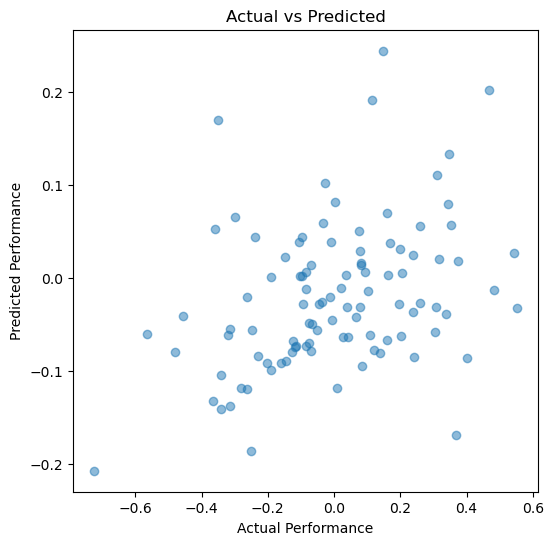

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Actual vs Predicted")
plt.show()

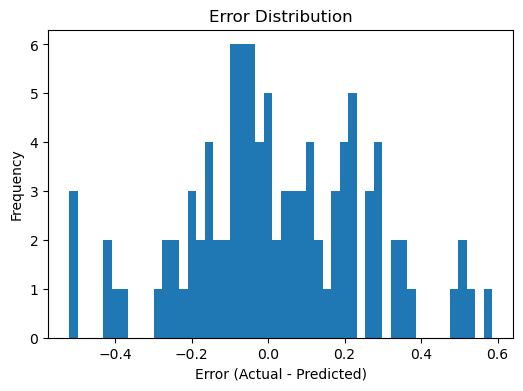

In [118]:
import matplotlib.pyplot as plt


errors = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

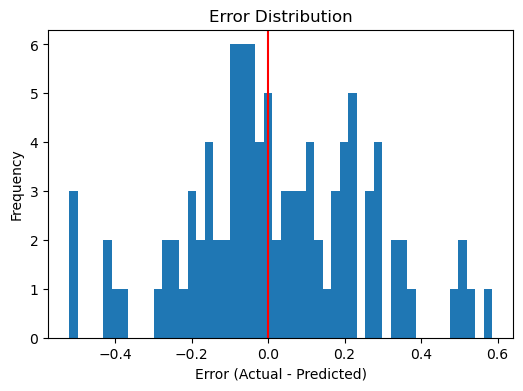

In [119]:
plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.axvline(0, color='red')  # zero error line
plt.title("Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Prepare data
X = df[features]
y = df["performance_year"]
X = X.fillna(X.median())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Coefficients
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

R²: 0.11966981286841993
MAE: 0.18297678222381342
RMSE: 0.23287151561636926
                         Feature  Coefficient
1           eps_growth_this_year     0.047210
8                 log_market_cap     0.043802
6              current_ratio_mrq     0.039454
0   quarterly_revenue_growth_yoy     0.018699
2           return_on_equity_ttm     0.008172
4               pricetosales_ttm     0.002952
5                pricetobook_mrq     0.000255
10   price_to_cash_per_share_mrq    -0.000012
9    price_to_free_cash_flow_ttm    -0.000076
7       total_debt_to_equity_mrq    -0.000506
3          net_profit_margin_ttm    -0.181550


## 5. Summary of Regression Findings

The multiple linear regression model was used to evaluate whether financial variables can explain variations in stock performance. The results indicate that while some relationships exist, the overall explanatory power of the model is limited.

---

## 📊 Model Performance

The model produced the following evaluation metrics:

- **R² = 0.12**
- **MAE = 0.183**
- **RMSE = 0.233**

### Interpretation

- The **R² value of 0.12** indicates that only about **12% of the variation in stock performance** is explained by the selected financial variables.
- This suggests that stock returns are only weakly driven by the included fundamentals, with a large portion influenced by other factors such as market sentiment, macroeconomic conditions, and investor expectations.
- The **MAE and RMSE values** indicate that prediction errors are relatively substantial, reinforcing that the model has limited predictive accuracy.

---

## 📊 Key Drivers of Stock Performance

### ✅ Positive Contributors

The variables with the strongest positive influence include:

- EPS Growth (`eps_growth_this_year`) — Coefficient: **0.047**
- Market Capitalization (`log_market_cap`) — Coefficient: **0.044**
- Current Ratio (`current_ratio_mrq`) — Coefficient: **0.039**
- Revenue Growth (`quarterly_revenue_growth_yoy`) — Coefficient: **0.019**

#### Interpretation

- Growth indicators (earnings and revenue growth) play an important role in explaining stock returns.
- Larger firms (via market capitalization) and companies with stronger liquidity positions also show slightly better performance.

---

### ❌ Negative Contributors

- Net Profit Margin (`net_profit_margin_ttm`) — Coefficient: **−0.182**
- Debt-to-Equity Ratio (`total_debt_to_equity_mrq`) — small negative effect

#### Interpretation

- The negative coefficient for net profit margin is counterintuitive and may indicate:
  - Multicollinearity among explanatory variables
  - Nonlinear relationships not captured by the model
  - Structural differences where high-margin firms are more mature and experience slower growth

- Higher leverage (debt) appears to slightly reduce performance, although the effect is weak.

---

### ⚖️ Weak or Insignificant Effects

- Price-to-Sales (P/S)
- Price-to-Book (P/B)
- Cash flow–based valuation measures

#### Interpretation

- Traditional valuation ratios show minimal influence on short-term stock performance.
- This aligns with earlier findings that valuation metrics alone are weak predictors of returns.

---

## 📊 Overall Insights

### 🔹 1. Limited explanatory power
Financial fundamentals explain only a small portion of stock performance, highlighting the complexity of financial markets.

### 🔹 2. Growth is the most important factor
Earnings and revenue growth variables show the strongest positive relationship with returns.

### 🔹 3. Valuation metrics are weak predictors
Ratios such as P/S and P/B provide limited explanatory value in this model.

### 🔹 4. Unexpected relationships exist
The negative relationship for net profit margin suggests:
- Possible interaction effects
- Limitations of linear modeling

### 🔹 5. Stock performance is highly noisy
The relatively high error metrics and low R² confirm that stock returns are difficult to predict using financial fundamentals alone.

---

## ✅ Conclusion

The regression analysis demonstrates that while financial variables — particularly growth indicators — do contribute to explaining stock performance, they are insufficient to fully capture market behavior.

The weak model fit highlights the importance of non-financial factors such as sentiment, macroeconomic conditions, and investor expectations. It also suggests that more advanced modeling techniques, such as machine learning models, may be required to better capture the underlying relationships.

## 6. Machine Learning Analysis (Random Forest)

### Question

**Can machine learning models better predict stock performance compared to linear regression?**

---

### Why This Matters

The regression analysis in the previous section showed:

- Low explanatory power (R² ≈ 0.12)
- Weak and sometimes inconsistent linear relationships between financial variables and stock performance

This suggests that:

> Stock returns are likely driven by complex, nonlinear interactions between financial variables that cannot be fully captured by a linear model.

---

### Why Random Forest?

To address these limitations, we apply a **Random Forest Regressor**, a machine learning model that:

- Captures **nonlinear relationships** between variables
- Automatically models **interactions between features**
- Is robust to **outliers and multicollinearity**
- Often performs better on **financial and market data**

---

### Objectives

This section aims to:

1. Build a Random Forest model to predict stock performance
2. Compare its performance with Linear Regression
3. Identify the most important predictive features
4. Evaluate whether nonlinear models improve predictive accuracy

---

### Expected Outcome

We expect the Random Forest model to:

- Improve predictive performance (higher R², lower error)
- Reveal complex relationships missed by linear regression
- Provide feature importance rankings for financial variables

---

### Methodology Overview

- Train-test split of dataset
- Model: Random Forest Regressor
- Evaluation metrics:
  - R² Score
  - MAE (Mean Absolute Error)
  - RMSE (Root Mean Squared Error)
- Feature importance analysis

In [120]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [121]:
y_pred_rf = rf.predict(X_test)

In [122]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R²: 0.31609464632997364
Random Forest MAE: 0.160223975
Random Forest RMSE: 0.20525397393521394


In [123]:
print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Linear Regression R²: 0.11966981286841993
Random Forest R²: 0.31609464632997364


In [124]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                         Feature  Importance
8                 log_market_cap    0.169195
0   quarterly_revenue_growth_yoy    0.121131
2           return_on_equity_ttm    0.119746
5                pricetobook_mrq    0.107616
1           eps_growth_this_year    0.087735
4               pricetosales_ttm    0.077182
10   price_to_cash_per_share_mrq    0.076471
3          net_profit_margin_ttm    0.072006
6              current_ratio_mrq    0.064515
7       total_debt_to_equity_mrq    0.054737
9    price_to_free_cash_flow_ttm    0.049666


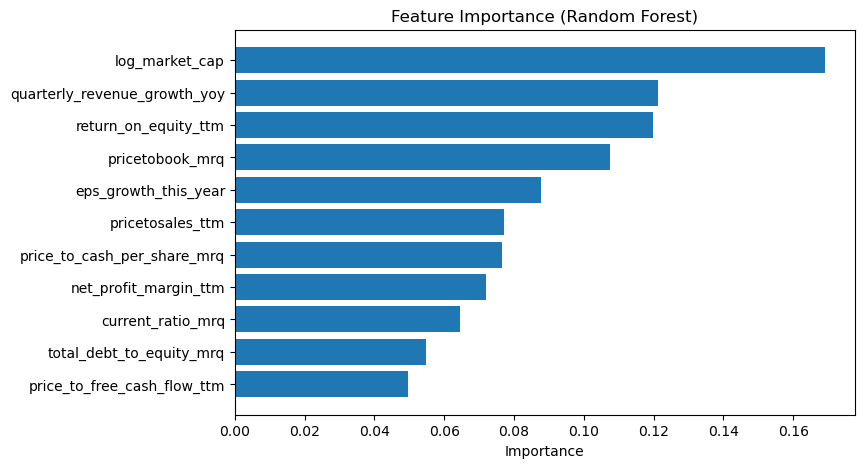

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

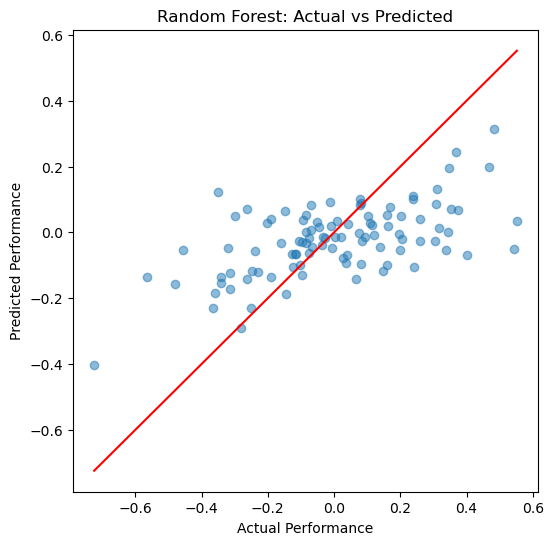

In [126]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)

import numpy as np
x = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x, x, color="red")

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [127]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R²:", scores.mean())

Cross-validated R²: 0.24729950064738943


## 6. Machine Learning Analysis (Random Forest)

### Objective

This section evaluates whether a machine learning model (Random Forest) can better predict stock performance compared to a traditional Linear Regression model.

The goal is to determine whether nonlinear relationships and feature interactions improve predictive accuracy.

---

## Model Comparison

### Linear Regression Performance

- **R² = 0.1197**

The linear regression model explains only about **12% of the variation** in stock performance, indicating weak linear relationships between financial variables and returns.

---

### Random Forest Performance

- **R² = 0.3161**
- **MAE = 0.1602**
- **RMSE = 0.2053**
- **Cross-validated R² = 0.2473**

---

## Interpretation of Results

The Random Forest model significantly outperforms Linear Regression:

- R² improves from **0.12 → 0.32**, indicating substantially better explanatory power.
- Lower MAE and RMSE values suggest improved prediction accuracy.
- Cross-validation confirms that the model generalizes reasonably well (R² ≈ 0.25).

### Key Insight

> Stock performance is better explained by nonlinear relationships and interactions between financial variables than by simple linear assumptions.

---

## Feature Importance Analysis

The Random Forest model identifies the most influential predictors of stock performance:

| Feature | Importance |
|----------|------------|
| log_market_cap | 0.169 |
| quarterly_revenue_growth_yoy | 0.121 |
| return_on_equity_ttm | 0.120 |
| pricetobook_mrq | 0.108 |
| eps_growth_this_year | 0.088 |
| pricetosales_ttm | 0.077 |
| price_to_cash_per_share_mrq | 0.076 |
| net_profit_margin_ttm | 0.072 |
| current_ratio_mrq | 0.065 |
| total_debt_to_equity_mrq | 0.055 |
| price_to_free_cash_flow_ttm | 0.050 |

---

## Interpretation of Feature Importance

### 1. Firm Size Matters Most
- **Market capitalization (log_market_cap)** is the most important predictor.
- Larger firms tend to show more stable and predictable performance patterns.

---

### 2. Growth Indicators Are Strong Drivers
- Revenue growth and EPS growth rank highly.
- This confirms that **growth expectations strongly influence stock returns**.

---

### 3. Profitability and Valuation Also Contribute
- ROE and net profit margin are important predictors.
- Valuation ratios (P/B, P/S, P/FCF) provide moderate predictive value.

---

### 4. Financial Health Has Moderate Influence
- Liquidity (current ratio) and leverage (debt-to-equity) have lower but meaningful importance.

---

## Overall Conclusion

The Random Forest model demonstrates that:

- Stock performance is influenced by **complex, nonlinear relationships**.
- Machine learning significantly improves predictive power compared to linear regression.
- No single financial metric dominates; instead, performance is driven by a combination of **size, growth, profitability, and valuation factors**.

### Final Insight

> While financial fundamentals provide useful signals, stock performance remains partially unpredictable, suggesting that external factors such as market sentiment, macroeconomic conditions, and investor behavior also play a major role.